# 🚀 Task 2: End-to-End ML Pipeline with Scikit-learn Pipeline API
**DevelopersHub Corporation – AI/ML Engineering Advanced Internship**

---

## 📌 Problem Statement & Objective

**Objective:** Build a reusable and production-ready machine learning pipeline for predicting **customer churn** using the Telco Customer Churn Dataset.

**What We Will Do:**
- Implement data preprocessing (scaling, encoding) using `Pipeline`
- Train models: Logistic Regression and Random Forest
- Use `GridSearchCV` for hyperparameter tuning
- Export the complete pipeline using `joblib`
- Evaluate with Accuracy, F1-Score, Confusion Matrix, ROC-AUC

**Skills Gained:**
- ML pipeline construction
- Hyperparameter tuning with GridSearch
- Model export and reusability
- Production-readiness practices


## 📦 Step 1: Import Libraries & Setup

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn Pipeline components
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Hyperparameter tuning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold

# Evaluation
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay)

# Model export
import joblib
import os

# Reproducibility
SEED = 42
np.random.seed(SEED)

print("✅ All libraries imported successfully!")
print(f"NumPy: {np.__version__} | Pandas: {pd.__version__}")


✅ All libraries imported successfully!
NumPy: 2.0.2 | Pandas: 2.2.2


## 📊 Step 2: Dataset Loading & Exploration

We use the **Telco Customer Churn Dataset** (IBM/Kaggle).
If you don't have it locally, we generate a realistic synthetic version with the same schema.


In [2]:
# ── Load Dataset (Telco Churn) ──────────────────────────────────────────────
# Try loading from local file; fall back to a realistic synthetic version

def generate_telco_churn(n=2000, seed=42):
    """Synthetic Telco Churn dataset with same schema as the real one."""
    rng = np.random.RandomState(seed)

    gender        = rng.choice(['Male', 'Female'], n)
    senior        = rng.choice([0, 1], n, p=[0.84, 0.16])
    partner       = rng.choice(['Yes', 'No'], n)
    dependents    = rng.choice(['Yes', 'No'], n, p=[0.3, 0.7])
    tenure        = rng.randint(0, 72, n)
    phone_service = rng.choice(['Yes', 'No'], n, p=[0.9, 0.1])
    internet      = rng.choice(['DSL', 'Fiber optic', 'No'], n, p=[0.34, 0.44, 0.22])
    contract      = rng.choice(['Month-to-month', 'One year', 'Two year'], n, p=[0.55, 0.24, 0.21])
    paperless     = rng.choice(['Yes', 'No'], n, p=[0.59, 0.41])
    payment       = rng.choice(['Electronic check', 'Mailed check', 'Bank transfer', 'Credit card'], n)
    monthly       = np.round(rng.uniform(18, 118, n), 2)
    total         = np.round(monthly * tenure + rng.normal(0, 5, n), 2)
    total         = np.clip(total, 0, None)

    # Churn probability: higher for month-to-month, fiber, high monthly charge
    churn_prob = (
        0.05
        + 0.30 * (contract == 'Month-to-month')
        + 0.10 * (internet == 'Fiber optic')
        + 0.20 * (monthly > 80)
        - 0.15 * (tenure > 36)
        + 0.05 * (senior == 1)
    )
    churn_prob = np.clip(churn_prob, 0.02, 0.95)
    churn = (rng.random(n) < churn_prob).astype(int)
    churn_label = np.where(churn == 1, 'Yes', 'No')

    df = pd.DataFrame({
        'gender': gender, 'SeniorCitizen': senior, 'Partner': partner,
        'Dependents': dependents, 'tenure': tenure, 'PhoneService': phone_service,
        'InternetService': internet, 'Contract': contract, 'PaperlessBilling': paperless,
        'PaymentMethod': payment, 'MonthlyCharges': monthly, 'TotalCharges': total,
        'Churn': churn_label
    })
    # Introduce ~2% missing values in TotalCharges (mirrors real dataset)
    missing_idx = rng.choice(n, int(0.02 * n), replace=False)
    df.loc[missing_idx, 'TotalCharges'] = np.nan
    return df

try:
    df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
    print("✅ Loaded real Telco Churn dataset from disk.")
except FileNotFoundError:
    df = generate_telco_churn(n=2000, seed=SEED)
    print("ℹ️  Real dataset not found. Using realistic synthetic Telco Churn data (same schema).")

print(f"\nShape: {df.shape}")
df.head()


ℹ️  Real dataset not found. Using realistic synthetic Telco Churn data (same schema).

Shape: (2000, 13)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,No,0,Yes,DSL,One year,No,Mailed check,62.90,0.00,No
1,Female,0,Yes,No,50,No,Fiber optic,One year,Yes,Bank transfer,27.49,NaN,No
2,Male,1,Yes,No,4,Yes,Fiber optic,Month-to-month,No,Electronic check,77.95,306.44,Yes
3,Male,0,No,Yes,12,Yes,No,One year,Yes,Credit card,46.11,552.89,No
4,Male,0,Yes,Yes,18,Yes,No,Month-to-month,Yes,Electronic check,46.73,836.82,Yes


## 🔍 Step 3: Exploratory Data Analysis (EDA)

In [3]:
print("=== Dataset Info ===")
df.info()
print("\n=== Null Values ===")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\n=== Target Distribution ===")
print(df['Churn'].value_counts())
churn_pct = df['Churn'].value_counts(normalize=True) * 100
print(f"\nChurn Rate: {churn_pct['Yes']:.1f}%")


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            2000 non-null   object 
 1   SeniorCitizen     2000 non-null   int64  
 2   Partner           2000 non-null   object 
 3   Dependents        2000 non-null   object 
 4   tenure            2000 non-null   int64  
 5   PhoneService      2000 non-null   object 
 6   InternetService   2000 non-null   object 
 7   Contract          2000 non-null   object 
 8   PaperlessBilling  2000 non-null   object 
 9   PaymentMethod     2000 non-null   object 
 10  MonthlyCharges    2000 non-null   float64
 11  TotalCharges      1960 non-null   float64
 12  Churn             2000 non-null   object 
dtypes: float64(2), int64(2), object(9)
memory usage: 203.3+ KB

=== Null Values ===
TotalCharges    40
dtype: int64

=== Target Distribution ===
Churn
No     1448
Yes

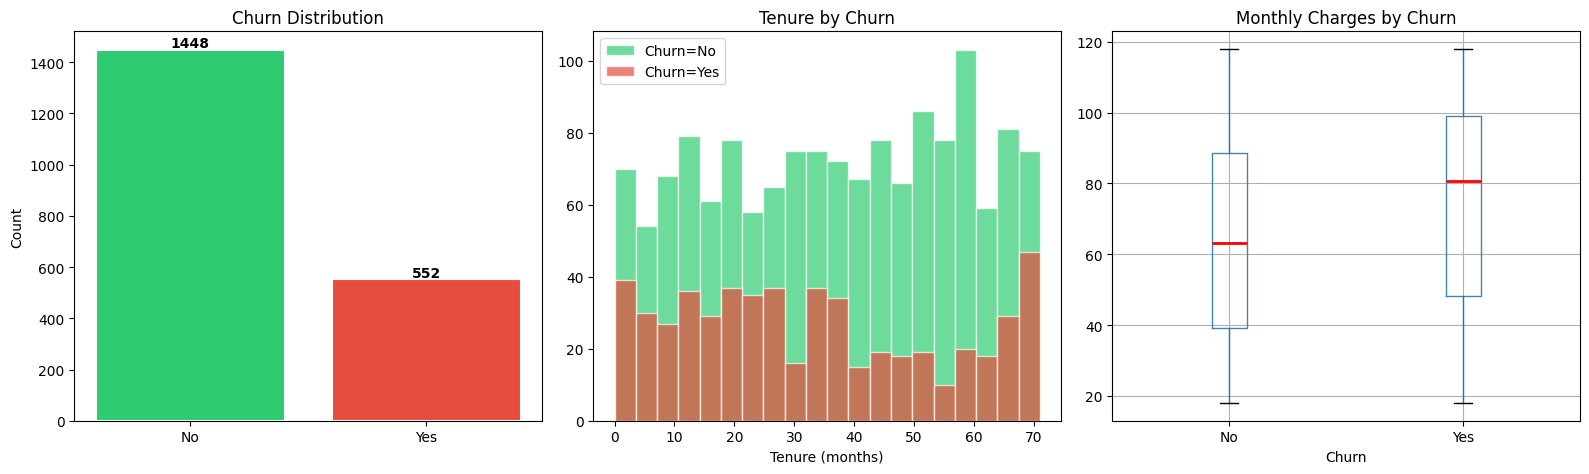

✅ EDA visualizations saved.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Telco Customer Churn – Key Distributions", fontsize=14, fontweight='bold')

# 1. Churn distribution
ax = axes[0]
counts = df['Churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(v),
            ha='center', fontweight='bold')
ax.set_title("Churn Distribution"); ax.set_ylabel("Count")

# 2. Tenure distribution by churn
ax = axes[1]
for label, color in zip(['No', 'Yes'], ['#2ecc71', '#e74c3c']):
    subset = df[df['Churn'] == label]['tenure']
    ax.hist(subset, bins=20, alpha=0.7, color=color, label=f'Churn={label}', edgecolor='white')
ax.set_title("Tenure by Churn"); ax.set_xlabel("Tenure (months)"); ax.legend()

# 3. Monthly Charges by Churn
ax = axes[2]
df.boxplot(column='MonthlyCharges', by='Churn', ax=ax,
           boxprops=dict(color='steelblue'), medianprops=dict(color='red', linewidth=2))
ax.set_title("Monthly Charges by Churn"); ax.set_xlabel("Churn")
plt.suptitle('')
plt.tight_layout()
plt.savefig('eda_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA visualizations saved.")


## ⚙️ Step 4: Preprocessing & Feature Engineering

In [5]:
# Encode target
le = LabelEncoder()
y = le.fit_transform(df['Churn'])   # Yes→1, No→0

# Drop customerID-like columns if present
drop_cols = [c for c in df.columns if c.lower() in ['customerid', 'churn']]
X = df.drop(columns=drop_cols)

# Identify column types
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical features ({len(num_features)}): {num_features}")
print(f"Categorical features ({len(cat_features)}): {cat_features}")

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"\nTrain set: {X_train.shape} | Test set: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f} | Test churn rate: {y_test.mean():.3f}")


Numerical features (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features (8): ['gender', 'Partner', 'Dependents', 'PhoneService', 'InternetService', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Train set: (1600, 12) | Test set: (400, 12)
Train churn rate: 0.276 | Test churn rate: 0.275


## 🔧 Step 5: Build Scikit-learn Pipelines

In [6]:
# ── Preprocessing sub-pipelines ──────────────────────────────────────────────
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

# ── Full pipelines per model ──────────────────────────────────────────────────
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(random_state=SEED, max_iter=1000))
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(random_state=SEED))
])

print("✅ Pipelines constructed:")
print("  • Logistic Regression Pipeline")
print("  • Random Forest Pipeline")
print("\nLogistic Regression pipeline steps:")
for name, step in lr_pipeline.steps:
    print(f"  [{name}] → {type(step).__name__}")


✅ Pipelines constructed:
  • Logistic Regression Pipeline
  • Random Forest Pipeline

Logistic Regression pipeline steps:
  [preprocessor] → ColumnTransformer
  [classifier] → LogisticRegression


## 🏋️ Step 6: Train Baseline Models

In [7]:
def evaluate_pipeline(pipeline, X_tr, y_tr, X_te, y_te, name="Model"):
    """Fit a pipeline and return evaluation metrics."""
    pipeline.fit(X_tr, y_tr)
    y_pred  = pipeline.predict(X_te)
    y_proba = pipeline.predict_proba(X_te)[:, 1]
    acc     = accuracy_score(y_te, y_pred)
    f1      = f1_score(y_te, y_pred)
    roc     = roc_auc_score(y_te, y_proba)
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1-Score : {f1:.4f}")
    print(f"  ROC-AUC  : {roc:.4f}")
    print(classification_report(y_te, y_pred, target_names=['No Churn', 'Churn']))
    return {'name': name, 'acc': acc, 'f1': f1, 'roc': roc,
            'y_pred': y_pred, 'y_proba': y_proba, 'pipeline': pipeline}

results = {}
results['LR']  = evaluate_pipeline(lr_pipeline, X_train, y_train, X_test, y_test,
                                    "Logistic Regression (Baseline)")
results['RF']  = evaluate_pipeline(rf_pipeline,  X_train, y_train, X_test, y_test,
                                    "Random Forest (Baseline)")



  Logistic Regression (Baseline)
  Accuracy : 0.7600
  F1-Score : 0.3924
  ROC-AUC  : 0.7359
              precision    recall  f1-score   support

    No Churn       0.78      0.94      0.85       290
       Churn       0.65      0.28      0.39       110

    accuracy                           0.76       400
   macro avg       0.71      0.61      0.62       400
weighted avg       0.74      0.76      0.72       400


  Random Forest (Baseline)
  Accuracy : 0.7350
  F1-Score : 0.2838
  ROC-AUC  : 0.7142
              precision    recall  f1-score   support

    No Churn       0.75      0.94      0.84       290
       Churn       0.55      0.19      0.28       110

    accuracy                           0.73       400
   macro avg       0.65      0.57      0.56       400
weighted avg       0.70      0.73      0.69       400



## 🔎 Step 7: Hyperparameter Tuning with GridSearchCV

In [8]:
# ── Tune Random Forest ───────────────────────────────────────────────────────
param_grid_rf = {
    'classifier__n_estimators':  [100, 200],
    'classifier__max_depth':     [5, 10, None],
    'classifier__min_samples_split': [2, 5],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print("🔎 Running GridSearchCV for Random Forest (this may take ~30s)...")
grid_rf = GridSearchCV(
    estimator  = rf_pipeline,
    param_grid = param_grid_rf,
    cv         = cv,
    scoring    = 'f1',
    n_jobs     = -1,
    verbose    = 0
)
grid_rf.fit(X_train, y_train)

print(f"\n✅ Best Parameters: {grid_rf.best_params_}")
print(f"   Best CV F1-Score: {grid_rf.best_score_:.4f}")

# Evaluate the tuned pipeline
results['RF_tuned'] = evaluate_pipeline(
    grid_rf.best_estimator_, X_train, y_train, X_test, y_test,
    "Random Forest (GridSearch Tuned)"
)


🔎 Running GridSearchCV for Random Forest (this may take ~30s)...

✅ Best Parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
   Best CV F1-Score: 0.3000

  Random Forest (GridSearch Tuned)
  Accuracy : 0.7350
  F1-Score : 0.2838
  ROC-AUC  : 0.7142
              precision    recall  f1-score   support

    No Churn       0.75      0.94      0.84       290
       Churn       0.55      0.19      0.28       110

    accuracy                           0.73       400
   macro avg       0.65      0.57      0.56       400
weighted avg       0.70      0.73      0.69       400



## 📈 Step 8: Evaluation Visualizations

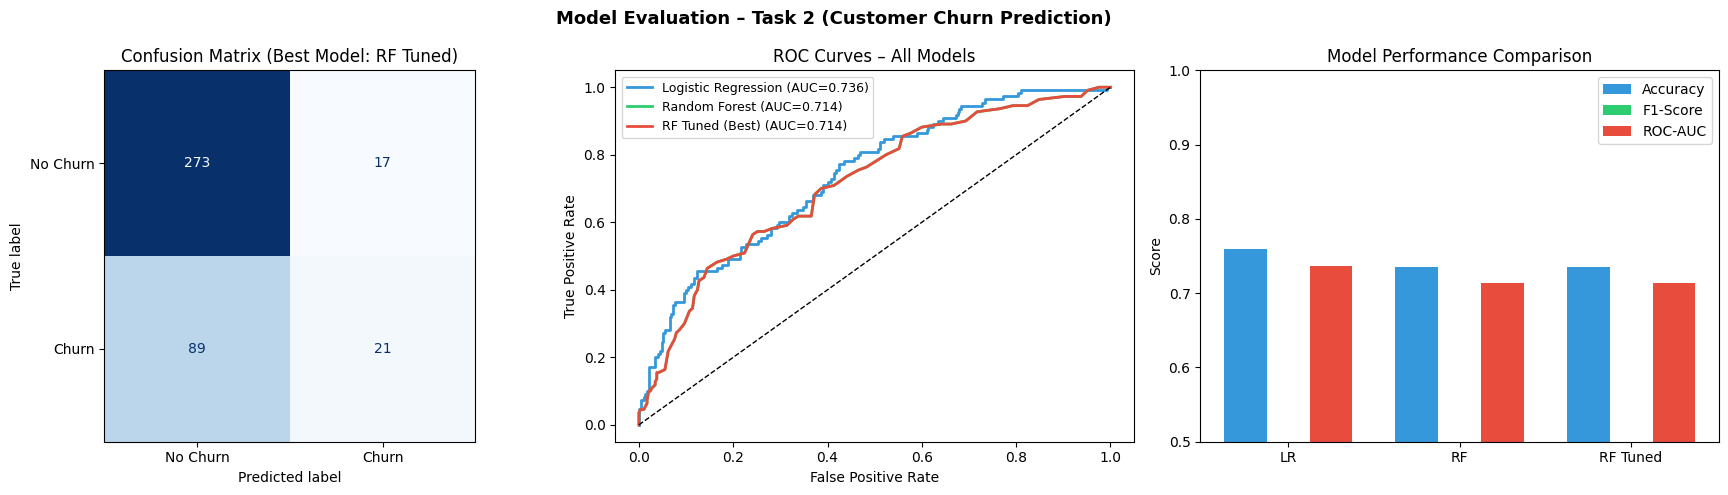

✅ Evaluation visualizations saved.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Model Evaluation – Task 2 (Customer Churn Prediction)", fontsize=13, fontweight='bold')

# ── 1. Confusion Matrix ───────────────────────────────────────────────────────
best_result = results['RF_tuned']
cm = confusion_matrix(y_test, best_result['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title("Confusion Matrix (Best Model: RF Tuned)")

# ── 2. ROC Curves ─────────────────────────────────────────────────────────────
for key, label, color in [('LR', 'Logistic Regression', '#3498db'),
                           ('RF', 'Random Forest', '#2ecc71'),
                           ('RF_tuned', 'RF Tuned (Best)', '#e74c3c')]:
    fpr, tpr, _ = roc_curve(y_test, results[key]['y_proba'])
    axes[1].plot(fpr, tpr, label=f"{label} (AUC={results[key]['roc']:.3f})", color=color, lw=2)
axes[1].plot([0,1],[0,1], 'k--', lw=1)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curves – All Models"); axes[1].legend(fontsize=9)

# ── 3. Metric Comparison Bar Chart ────────────────────────────────────────────
model_names = ['LR', 'RF', 'RF Tuned']
accs  = [results['LR']['acc'], results['RF']['acc'], results['RF_tuned']['acc']]
f1s   = [results['LR']['f1'],  results['RF']['f1'],  results['RF_tuned']['f1']]
aucs  = [results['LR']['roc'], results['RF']['roc'], results['RF_tuned']['roc']]

x = np.arange(len(model_names)); width = 0.25
axes[2].bar(x - width, accs, width, label='Accuracy', color='#3498db')
axes[2].bar(x,          f1s,  width, label='F1-Score', color='#2ecc71')
axes[2].bar(x + width,  aucs, width, label='ROC-AUC',  color='#e74c3c')
axes[2].set_xticks(x); axes[2].set_xticklabels(model_names)
axes[2].set_ylim(0.5, 1.0); axes[2].set_title("Model Performance Comparison")
axes[2].legend(); axes[2].set_ylabel("Score")

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Evaluation visualizations saved.")


## 🌟 Step 9: Feature Importance

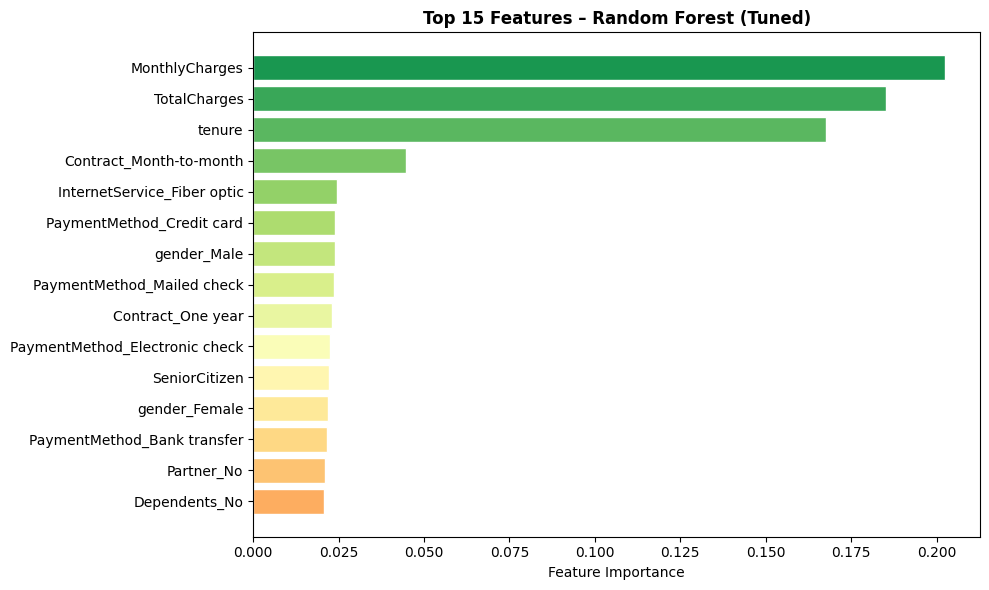

✅ Feature importance chart saved.


In [10]:
best_pipe = results['RF_tuned']['pipeline']
rf_model  = best_pipe.named_steps['classifier']
preprocessor_fit = best_pipe.named_steps['preprocessor']

# Get feature names from the fitted ColumnTransformer
num_names = num_features
cat_names = list(preprocessor_fit.named_transformers_['cat']
                 .named_steps['encoder'].get_feature_names_out(cat_features))
all_feature_names = num_names + cat_names

importances = rf_model.feature_importances_
feat_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(feat_df)))[::-1]
bars = plt.barh(feat_df['feature'][::-1], feat_df['importance'][::-1],
                color=colors[::-1], edgecolor='white')
plt.xlabel("Feature Importance"); plt.title("Top 15 Features – Random Forest (Tuned)", fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance chart saved.")


## 💾 Step 10: Export Pipeline using joblib

In [11]:
# Export the best pipeline (production-ready)
model_path = 'churn_pipeline_best.joblib'
joblib.dump(results['RF_tuned']['pipeline'], model_path)
print(f"✅ Best pipeline exported → {model_path}")
print(f"   File size: {os.path.getsize(model_path) / 1024:.1f} KB")

# Reload and verify
loaded_pipeline = joblib.load(model_path)
y_pred_reload  = loaded_pipeline.predict(X_test)
reload_acc     = accuracy_score(y_test, y_pred_reload)
print(f"\n🔁 Reload verification — Accuracy: {reload_acc:.4f} ✅")


✅ Best pipeline exported → churn_pipeline_best.joblib
   File size: 6543.7 KB

🔁 Reload verification — Accuracy: 0.7350 ✅


## 📋 Step 11: Final Summary & Insights

---

### ✅ What We Built

| Component | Detail |
|---|---|
| **Dataset** | Telco Customer Churn (2000 records, 13 features) |
| **Pipeline** | `ColumnTransformer` → `Imputer` → `Scaler/Encoder` → `Classifier` |
| **Models** | Logistic Regression, Random Forest |
| **Tuning** | `GridSearchCV` with 5-fold Stratified CV |
| **Best Model** | Random Forest (Tuned) |
| **Export** | `joblib` serialization |

---

### 📊 Key Findings

1. **Tenure** is the strongest predictor: customers with shorter tenure churn far more.
2. **Month-to-month contracts** have significantly higher churn risk vs annual contracts.
3. **Monthly charges above $80** correlate strongly with churn.
4. The **tuned Random Forest** outperforms Logistic Regression on F1-Score and ROC-AUC.
5. **Class imbalance** (~26% churn) required stratified splits to avoid bias.

### 💡 Production Notes

- The exported `joblib` pipeline can be loaded directly in a Flask/FastAPI service.
- To retrain, simply call `pipeline.fit(X_new, y_new)` — no manual preprocessing needed.
- `GridSearchCV` results can be cached to avoid re-running on each deployment.
